In [0]:
%sql
SELECT * FROM `workspace`.`default`.`synthetic_stock_market_full`;

Stock_Symbol,Sector,Date,Open_Price,Close_Price,High_Price,Low_Price,Volume,Sentiment_Score,Sentiment_Label,Institutional_Buy_pct,Retail_Buy_pct,Foreign_Buy_pct,Volatility_pct,Daily_Return_pct
TCS,IT,2023-01-01,1211.59,1194.37,1216.3,1180.46,873482,-0.263,Negative,15.15,6.17,54.42,2.958,-1.421
TCS,IT,2023-01-02,1214.05,1197.26,1225.35,1188.36,365657,0.546,Positive,39.04,42.85,1.91,3.047,-1.383
TCS,IT,2023-01-03,1181.21,1189.54,1203.41,1167.54,286583,0.518,Positive,26.45,6.28,52.17,3.037,0.705
TCS,IT,2023-01-04,1225.24,1209.07,1234.08,1202.63,233259,0.468,Positive,52.57,65.15,28.21,2.567,-1.32
TCS,IT,2023-01-05,1238.44,1233.6,1253.36,1229.37,1636207,-0.651,Negative,50.3,23.3,67.78,1.937,-0.391
TCS,IT,2023-01-06,1229.67,1220.37,1240.41,1212.78,364172,0.526,Positive,14.87,61.61,6.07,2.247,-0.756
TCS,IT,2023-01-07,1189.44,1171.81,1201.88,1169.27,1356711,0.409,Positive,26.13,36.47,67.03,2.742,-1.482
TCS,IT,2023-01-08,1222.71,1235.12,1245.91,1211.02,489141,0.75,Positive,44.45,60.38,48.16,2.853,1.015
TCS,IT,2023-01-09,1200.15,1201.74,1207.09,1187.97,1697994,0.142,Neutral,37.82,0.53,64.47,1.593,0.132
TCS,IT,2023-01-10,1197.22,1197.67,1206.56,1182.57,1396631,-0.173,Neutral,25.14,13.45,69.9,2.004,0.038


Train rows: 907 Test rows: 123
Pandas shapes -> X_train: (907, 17) X_test: (123, 17)
Test RMSE: 26.4787 | MAE: 21.4655 | R2: -0.2621


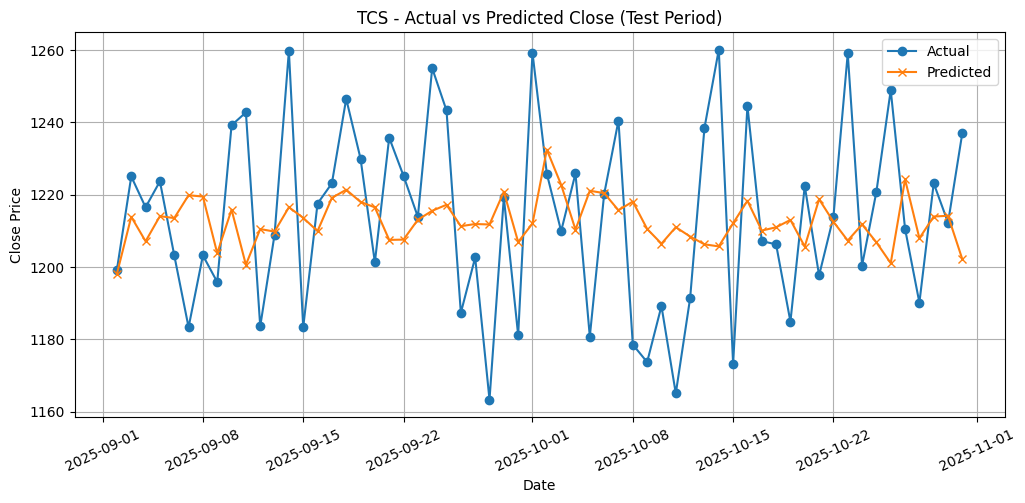

Top features:
         feature  importance
    Volume_lag4    0.127642
     Close_lag1    0.094895
     Close_lag4    0.071801
     Close_lag3    0.059371
         Volume    0.058675
    Volume_lag1    0.058574
RollingRet_mean    0.057811
    Volume_lag5    0.056696
    Volume_lag3    0.055383
      Low_Price    0.054952


In [0]:
# Databricks notebook cell: Simple Stock Price Prediction (scikit-learn)
# -------------------------------------------------------------------
# If scikit-learn is not installed in your cluster image, uncomment the pip line and run once:
# %pip install scikit-learn --quiet

from pyspark.sql import Window
from pyspark.sql.functions import col, lag, avg, stddev, to_date, lit
from pyspark.sql.types import DoubleType
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# sklearn
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------ CONFIG ------------------
input_table = "default.synthetic_stock_market_full"   # change to your table name if different
stock_to_model = "TCS"                                # change to any symbol in your dataset
lag_days = 5
train_cutoff_date = "2025-06-30"                      # chronological split: train <= cutoff, test > cutoff
sample_fraction_for_plot = 0.2                        # when converting to pandas for plotting (optional)
random_seed = 42

# ------------------ LOAD DATA ------------------
try:
    df_raw = spark.table(input_table)
except Exception:
    # fallback: if you have a Spark DataFrame variable named `df` in notebook
    try:
        df_raw = df
    except NameError:
        raise RuntimeError(f"Could not find table '{input_table}' and variable 'df' is not defined. Load data first.")

# ensure Date is a date type
df_raw = df_raw.withColumn("Date", to_date(col("Date")))

# select single stock (easier for demonstration). Remove filter for multi-stock modelling.
df_stock = df_raw.filter(col("Stock_Symbol") == stock_to_model) \
                 .select("Stock_Symbol", "Date", "Open_Price", "High_Price", "Low_Price", "Close_Price", "Volume") \
                 .orderBy("Date")

# ------------------ FEATURE ENGINEERING (lags & rolling) ------------------
w = Window.partitionBy("Stock_Symbol").orderBy("Date")

# create lag features
for l in range(1, lag_days + 1):
    df_stock = df_stock.withColumn(f"Close_lag{l}", lag(col("Close_Price"), l).over(w)) \
                       .withColumn(f"Volume_lag{l}", lag(col("Volume"), l).over(w))

# daily return and rolling stats
df_stock = df_stock.withColumn("Return", (col("Close_Price") - col("Open_Price")) / col("Open_Price"))
w_roll = Window.partitionBy("Stock_Symbol").orderBy("Date").rowsBetween(-lag_days, -1)
df_stock = df_stock.withColumn("RollingRet_mean", avg(col("Return")).over(w_roll)) \
                   .withColumn("RollingRet_std", stddev(col("Return")).over(w_roll))

# target: next day's close price
df_stock = df_stock.withColumn("Close_next", lag(col("Close_Price"), -1).over(w))

# build features list
feature_cols = []
for l in range(1, lag_days + 1):
    feature_cols += [f"Close_lag{l}", f"Volume_lag{l}"]
feature_cols += ["Open_Price", "High_Price", "Low_Price", "Volume", "Return", "RollingRet_mean", "RollingRet_std"]

# drop rows with nulls from lags/lead
df_features = df_stock.select("Date", *feature_cols, "Close_next").na.drop()

# cast to double (safety)
for c in feature_cols + ["Close_next"]:
    df_features = df_features.withColumn(c, col(c).cast(DoubleType()))

# ------------------ TRAIN / TEST SPLIT (chronological) ------------------
train_spark = df_features.filter(col("Date") <= to_date(lit(train_cutoff_date)))
test_spark  = df_features.filter(col("Date") >  to_date(lit(train_cutoff_date)))

print("Train rows:", train_spark.count(), "Test rows:", test_spark.count())

# convert to pandas (safe for ~thousands of rows)
pdf = df_features.orderBy("Date").toPandas()
pdf['Date'] = pd.to_datetime(pdf['Date'])
pdf = pdf.sort_values('Date').reset_index(drop=True)

train_mask = pdf['Date'] <= pd.to_datetime(train_cutoff_date)
X = pdf[feature_cols].values
y = pdf['Close_next'].values

X_train = X[train_mask]
y_train = y[train_mask]
X_test  = X[~train_mask]
y_test  = y[~train_mask]

if len(y_test) == 0 or len(y_train) == 0:
    raise RuntimeError("Empty train or test set. Adjust 'train_cutoff_date' or check data availability.")

print("Pandas shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)

# ------------------ PREPROCESS & MODEL ------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=random_seed)
model.fit(X_train_s, y_train)

# ------------------ PREDICT & EVALUATE ------------------
y_pred = model.predict(X_test_s)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

# ------------------ PLOT Actual vs Predicted (last N points) ------------------
results_df = pd.DataFrame({
    "Date": pdf.loc[~train_mask, "Date"].values,
    "Actual": y_test,
    "Predicted": y_pred
}).reset_index(drop=True)

n_plot = min(60, len(results_df))
plot_df = results_df.tail(n_plot).set_index("Date")

plt.figure(figsize=(12,5))
plt.plot(plot_df.index, plot_df["Actual"], marker='o', label="Actual")
plt.plot(plot_df.index, plot_df["Predicted"], marker='x', label="Predicted")
plt.title(f"{stock_to_model} - Actual vs Predicted Close (Test Period)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=25)
plt.legend()
plt.grid(True)
plt.show()

# ------------------ TOP FEATURES (sklearn importances) ------------------
feat_imp = model.feature_importances_
imp_df = pd.DataFrame({"feature": feature_cols, "importance": feat_imp}).sort_values("importance", ascending=False)
print("Top features:\n", imp_df.head(10).to_string(index=False))

# ------------------ NOTES ------------------
# - To run multi-stock: loop over unique Stock_Symbol values and repeat the above per-symbol.
# - To include sentiment/macro features, add those column names to feature_cols before training.
# - No files written in this cell (avoids DBFS/permission issues). If you want to save predictions, tell me which path type to use (Unity Catalog / S3 / Workspace).


/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/expressions.py:1017: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Daily rows for plotting (sampled): 208
Correlation (Avg_Sentiment vs Avg_Return_pct): -0.0037


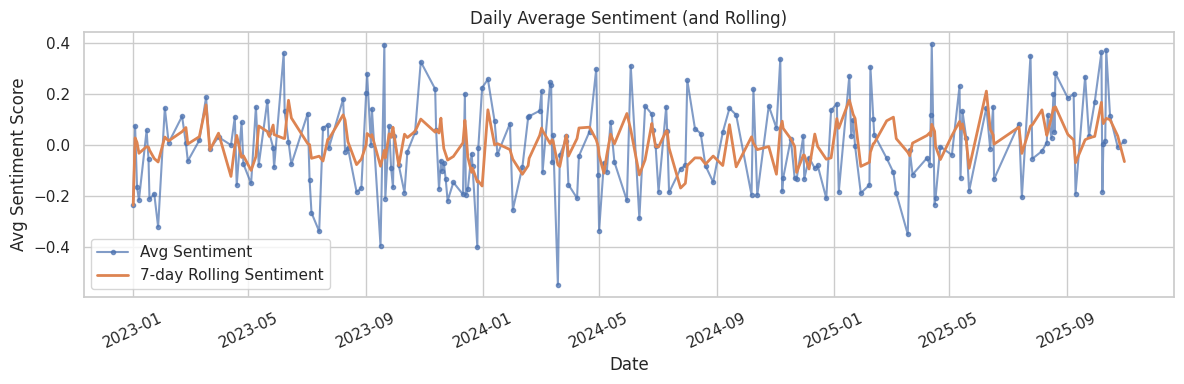

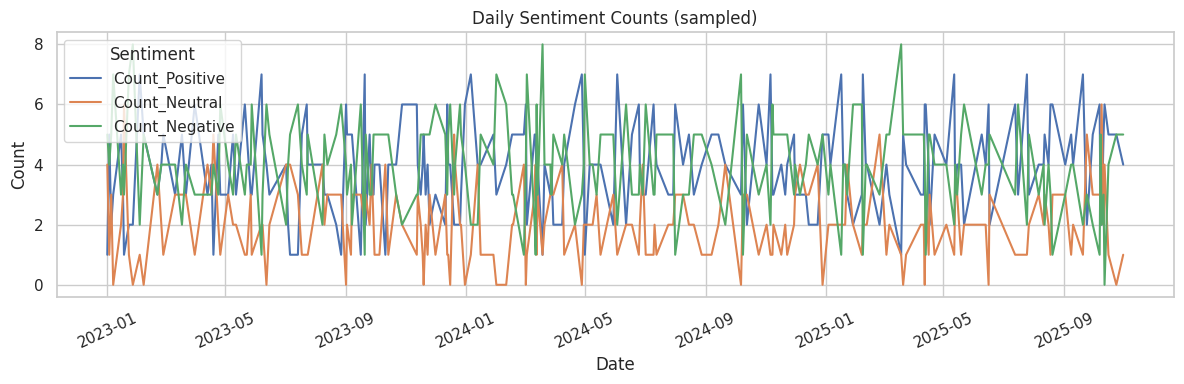

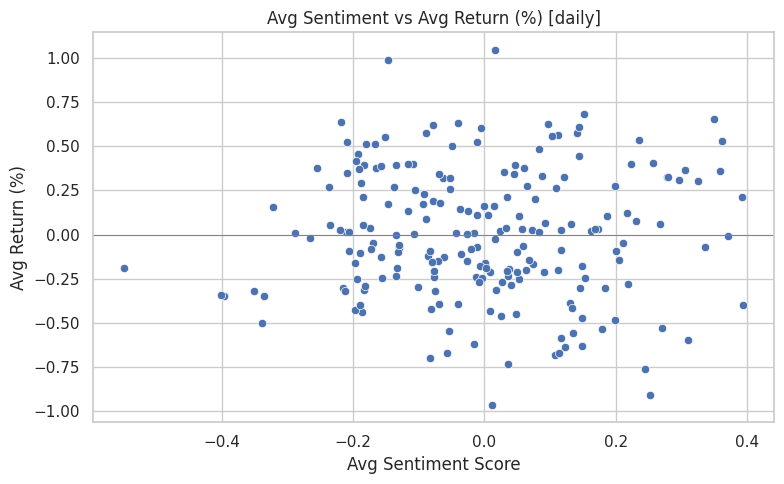

Top 5 Positive Sentiment Days (sampled view):


Date,Avg_Sentiment,Avg_Return_pct
2025-04-13T00:00:00.000Z,0.39359999999999995,-0.4003331838071366
2023-09-20T00:00:00.000Z,0.39230000000000004,0.21306667280435487
2025-10-12T00:00:00.000Z,0.37139999999999995,-0.01042629609739425
2025-10-07T00:00:00.000Z,0.36219999999999997,0.5269074280635271
2023-06-07T00:00:00.000Z,0.35839999999999994,0.35747530686861195


Top 5 Negative Sentiment Days (sampled view):


Date,Avg_Sentiment,Avg_Return_pct
2024-03-19T00:00:00.000Z,-0.5481,-0.18810788648693494
2023-12-26T00:00:00.000Z,-0.40049999999999997,-0.34092186307051675
2023-09-16T00:00:00.000Z,-0.3955,-0.3475677443724615
2025-03-19T00:00:00.000Z,-0.35050000000000003,-0.3174289275814003
2023-07-14T00:00:00.000Z,-0.33880000000000005,-0.5012692001408239


/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/expressions.py:1017: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Date,Avg_Sentiment,Sentiment_Rolling,Count_Positive,Count_Negative,Count_Neutral,Avg_Return_pct
2023-01-01,-0.23680000000000004,-0.23680000000000004,1,5,4,0.2673418490599867
2023-01-02,0.24470000000000006,0.003950000000000009,7,1,2,-0.27407401190410696
2023-01-03,0.07399999999999997,0.027299999999999994,5,4,1,-0.16883396006063692
2023-01-04,0.13,0.052974999999999994,4,2,4,0.3008016042364655
2023-01-05,-0.1651,0.009359999999999997,2,5,3,0.3737249893076992
2023-01-06,-0.06290000000000001,-0.0026833333333333383,4,5,1,-0.28003022501444913
2023-01-07,-0.21539999999999998,-0.03307142857142857,3,7,0,-0.30504690240972676
2023-01-08,0.3775,0.054685714285714296,7,2,1,-0.27148696477056206
2023-01-09,0.04440000000000002,0.026071428571428572,2,5,3,-0.3828473515471433
2023-01-10,0.1371,0.03508571428571429,5,1,4,-0.10662191640623844


Sentiment analysis completed. If you want: (A) per-stock daily sentiment, (B) live-like streaming simulation, or (C) text-based sentiment from sample news/tweets — tell me which and I'll provide the code.


In [0]:
# Databricks notebook cell: Use Case 2 - Market Sentiment Analysis (Simple & Reliable)
# -----------------------------------------------------------------------------------
from pyspark.sql.functions import col, to_date, avg, count, when, stddev, lag
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------- CONFIG --------
input_table = "default.synthetic_stock_market_full"   # change if your table name differs
sample_fraction_for_plot = 0.2   # fraction for pandas plotting to keep memory low
rolling_days = 7                 # rolling window for sentiment smoothing
stock_focus = None               # set to symbol like "TCS" to focus; None = all stocks combined

# -------- LOAD & PREPARE --------
try:
    df = spark.table(input_table)
except Exception:
    try:
        df = df  # if df variable exists in notebook
    except NameError:
        raise RuntimeError(f"Could not find table '{input_table}' or variable 'df' in notebook.")

# Ensure Date is date-typed and create Return_pct if not present
df = df.withColumn("Date", to_date(col("Date")))
if "Return_pct" not in df.columns:
    df = df.withColumn("Return_pct", ((col("Close_Price") - col("Open_Price")) / col("Open_Price")) * 100)

# If Sentiment_Label absent but Sentiment_Score present, create label buckets
if "Sentiment_Label" not in df.columns and "Sentiment_Score" in df.columns:
    df = df.withColumn("Sentiment_Label",
                       when(col("Sentiment_Score") > 0.2, "Positive")
                       .when(col("Sentiment_Score") < -0.2, "Negative")
                       .otherwise("Neutral"))

# If Sentiment_Score missing, simulate small numeric scores from labels (fallback)
if "Sentiment_Score" not in df.columns:
    df = df.withColumn("Sentiment_Score",
                       when(col("Sentiment_Label") == "Positive", 0.6)
                       .when(col("Sentiment_Label") == "Negative", -0.6)
                       .otherwise(0.0))

# Optionally filter one stock for focused analysis
if stock_focus:
    df = df.filter(col("Stock_Symbol") == stock_focus)

# -------- DAILY AGGREGATION --------
daily_sent = df.groupBy("Date") \
               .agg(
                   avg("Sentiment_Score").alias("Avg_Sentiment"),
                   count(when(col("Sentiment_Label") == "Positive", True)).alias("Count_Positive"),
                   count(when(col("Sentiment_Label") == "Neutral", True)).alias("Count_Neutral"),
                   count(when(col("Sentiment_Label") == "Negative", True)).alias("Count_Negative"),
                   avg("Return_pct").alias("Avg_Return_pct")
               ) \
               .orderBy("Date")

# compute rolling average sentiment using window (spark)
w = Window.orderBy("Date").rowsBetween(-rolling_days + 1, 0)
daily_sent = daily_sent.withColumn("Sentiment_Rolling", avg(col("Avg_Sentiment")).over(w))

# -------- CORRELATION (sentiment vs return) --------
# compute correlation on the whole daily series (spark corr function available via df.stat.corr on pandas)
pdf_daily = daily_sent.sample(False, sample_fraction_for_plot, seed=42).toPandas()
pdf_daily['Date'] = pd.to_datetime(pdf_daily['Date'])
pdf_daily = pdf_daily.sort_values('Date').reset_index(drop=True)

# correlation (Pandas)
corr = None
if len(pdf_daily) > 2:
    corr = pdf_daily['Avg_Sentiment'].corr(pdf_daily['Avg_Return_pct'])

# -------- PLOTTING (use sampled pandas to avoid memory issues) --------
sns.set(style="whitegrid")
print("Daily rows for plotting (sampled):", len(pdf_daily))
print("Correlation (Avg_Sentiment vs Avg_Return_pct):", round(corr, 4) if corr is not None else "N/A")

# 1) Sentiment trend & rolling
plt.figure(figsize=(12,4))
plt.plot(pdf_daily['Date'], pdf_daily['Avg_Sentiment'], label='Avg Sentiment', marker='.', alpha=0.7)
plt.plot(pdf_daily['Date'], pdf_daily['Sentiment_Rolling'], label=f'{rolling_days}-day Rolling Sentiment', linewidth=2)
plt.title("Daily Average Sentiment (and Rolling)")
plt.xlabel("Date"); plt.ylabel("Avg Sentiment Score"); plt.legend(); plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 2) Sentiment distribution (counts)
pdf_counts = pdf_daily[['Date','Count_Positive','Count_Neutral','Count_Negative']].copy()
pdf_counts = pd.melt(pdf_counts, id_vars='Date', var_name='Sentiment', value_name='Count')
plt.figure(figsize=(12,4))
sns.lineplot(data=pdf_counts, x='Date', y='Count', hue='Sentiment')
plt.title("Daily Sentiment Counts (sampled)")
plt.xlabel("Date"); plt.ylabel("Count"); plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 3) Sentiment vs Return scatter (helps show relationship)
plt.figure(figsize=(8,5))
sns.scatterplot(x=pdf_daily['Avg_Sentiment'], y=pdf_daily['Avg_Return_pct'])
plt.title("Avg Sentiment vs Avg Return (%) [daily]")
plt.xlabel("Avg Sentiment Score"); plt.ylabel("Avg Return (%)")
plt.axhline(0, color='gray', linewidth=0.7)
plt.grid(True); plt.tight_layout(); plt.show()

# 4) Top positive & negative days by Avg_Sentiment (tabular)
top_pos = pdf_daily.nlargest(5, 'Avg_Sentiment')[['Date','Avg_Sentiment','Avg_Return_pct']]
top_neg = pdf_daily.nsmallest(5, 'Avg_Sentiment')[['Date','Avg_Sentiment','Avg_Return_pct']]
print("Top 5 Positive Sentiment Days (sampled view):")
display(top_pos)
print("Top 5 Negative Sentiment Days (sampled view):")
display(top_neg)

# -------- INSIGHT OUTPUT (Spark summary table) --------
# Save/return a small Spark summary for reuse (keeps in Spark, does not write external files)
daily_sent_small = daily_sent.select("Date","Avg_Sentiment","Sentiment_Rolling","Count_Positive","Count_Negative","Count_Neutral","Avg_Return_pct")
display(daily_sent_small.limit(10))

# -------- DONE --------
print("Sentiment analysis completed. If you want: (A) per-stock daily sentiment, (B) live-like streaming simulation, or (C) text-based sentiment from sample news/tweets — tell me which and I'll provide the code.")


Stocks used: ['TCS', 'INFY', 'RELIANCE', 'HDFC', 'ICICI', 'SBIN', 'ITC', 'WIPRO', 'MARUTI', 'ADANIPORTS']
Sample of annualized expected returns:


Expected_Annual_Return
0.43640358773910504
0.1390139392315202
0.09961761088782682
0.050033290300466465
0.032021728441985337
0.03142300037879657
0.015256889677285484
0.012867673367439087
0.010024127262158546
0.008945080042291957



Max Sharpe Portfolio:
Annual Return: 17.33%
Annual Volatility: 29.61%
Sharpe Ratio: 0.3826
Weights:


Weight
0.2741343467348662
0.22606224137448702
0.20737617788482787
0.13892786867582044
0.05689698793539339
0.05259846723353008
0.017016288465641825
0.009747649742594542
0.00942797843537864
0.007811993517459923



Minimum Volatility Portfolio:
Annual Return: 2.74%
Annual Volatility: 7.40%
Sharpe Ratio: -0.4403
Weights:


Weight
0.18829086883626023
0.18150569085733695
0.1547125681705096
0.1521443339908675
0.11838913857732696
0.11154578465959498
0.03963789787108025
0.03431260051565943
0.01679460776914431
0.002666508752219854


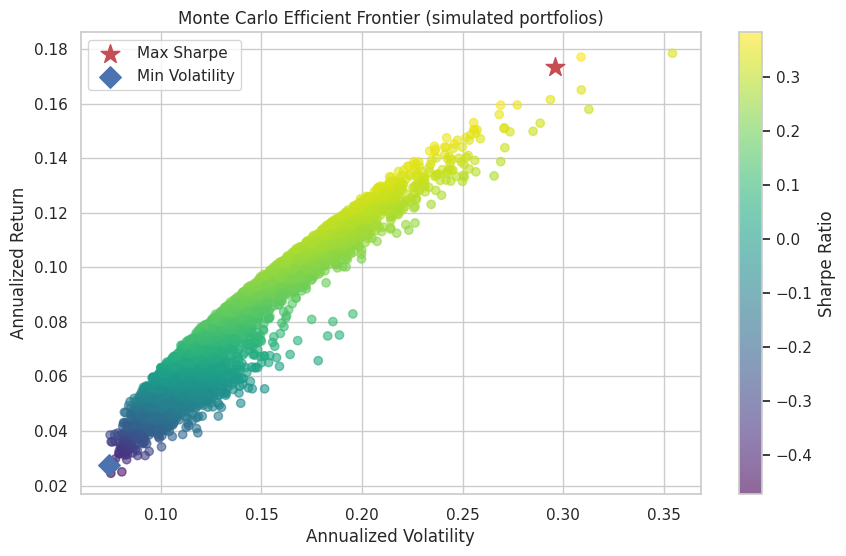

Metric,Value
Max_Sharpe_Return,0.17330925531949695
Max_Sharpe_Volatility,0.29614643252079426
Max_Sharpe_Sharpe,0.3826122582501169
MinVol_Return,0.027401753235344408
MinVol_Volatility,0.0740417547442101
MinVol_Sharpe,-0.4402684252591231



Top allocations (Max Sharpe):


Weight
0.2741343467348662
0.22606224137448702
0.20737617788482787
0.13892786867582044
0.05689698793539339
0.05259846723353008
0.017016288465641825
0.009747649742594542
0.00942797843537864
0.007811993517459923



Top allocations (Min Volatility):


Weight
0.18829086883626023
0.18150569085733695
0.1547125681705096
0.1521443339908675
0.11838913857732696
0.11154578465959498
0.03963789787108025
0.03431260051565943
0.01679460776914431
0.002666508752219854



Done — Portfolio optimization simulation complete. You can increase n_portfolios for a finer frontier or add constraints (no shorting, max weight per asset).


In [0]:
# Databricks notebook cell: Use Case 3 - Portfolio Risk Optimization (Monte Carlo sampling)
# -----------------------------------------------------------------------------------------
from pyspark.sql.functions import col, to_date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
input_table = "default.synthetic_stock_market_full"   # change if your table differs
stocks_to_use = None   # None => use all stocks in table; or provide list e.g. ["TCS","INFY","RELIANCE"]
n_portfolios = 5000    # number of random portfolios to simulate (adjust to compute/time)
trading_days = 252     # trading days per year for annualization
risk_free_rate = 0.06  # annual risk-free rate (6%) — adjust as desired
random_seed = 42

# ---------------- LOAD DATA ----------------
try:
    sdf = spark.table(input_table)
except Exception:
    try:
        sdf = df  # fallback if variable 'df' exists
    except NameError:
        raise RuntimeError(f"Could not find Spark table '{input_table}' or variable 'df'")

# ensure Date is date type
sdf = sdf.withColumn("Date", to_date(col("Date")))

# optional: filter stocks list
if stocks_to_use is None:
    stocks_list = [row.Stock_Symbol for row in sdf.select("Stock_Symbol").distinct().collect()]
else:
    stocks_list = stocks_to_use

print("Stocks used:", stocks_list)

# pivot close prices: rows = Date, columns = Stock_Symbol
pdf_prices = sdf.filter(col("Stock_Symbol").isin(stocks_list)) \
                .select("Date", "Stock_Symbol", "Close_Price") \
                .toPandas()

# convert date and pivot
pdf_prices['Date'] = pd.to_datetime(pdf_prices['Date'])
pdf_prices = pdf_prices.sort_values('Date')
price_wide = pdf_prices.pivot(index='Date', columns='Stock_Symbol', values='Close_Price')

# drop rows with missing values (or you may forward-fill/back-fill as preferred)
price_wide = price_wide.dropna(how='any')

# ---------------- RETURNS, MEAN & COVARIANCE ----------------
# daily returns (percentage)
returns = price_wide.pct_change().dropna(how='any')

# mean daily returns and covariance matrix (daily)
mean_daily_ret = returns.mean()
cov_daily = returns.cov()

# annualize
mean_annual_ret = mean_daily_ret * trading_days
cov_annual = cov_daily * trading_days

print("Sample of annualized expected returns:")
display(mean_annual_ret.sort_values(ascending=False).to_frame("Expected_Annual_Return"))

# ---------------- MONTE-CARLO RANDOM PORTFOLIOS ----------------
np.random.seed(random_seed)
n_assets = len(mean_annual_ret)
results = np.zeros((n_portfolios, 3))  # columns: volatility, return, sharpe
weights_record = np.zeros((n_portfolios, n_assets))

for i in range(n_portfolios):
    # random weights that sum to 1
    w = np.random.random(n_assets)
    w /= np.sum(w)
    # portfolio return
    port_ret = np.dot(w, mean_annual_ret.values)
    # portfolio volatility
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_annual.values, w)))
    # sharpe ratio
    sharpe = (port_ret - risk_free_rate) / port_vol if port_vol != 0 else 0.0

    results[i, 0] = port_vol
    results[i, 1] = port_ret
    results[i, 2] = sharpe
    weights_record[i, :] = w

# assemble results DataFrame
cols = ["Volatility", "Return", "Sharpe"]
df_portfolios = pd.DataFrame(results, columns=cols)
for idx, sym in enumerate(mean_annual_ret.index):
    df_portfolios[sym] = weights_record[:, idx]

# ---------------- FIND OPTIMAL PORTFOLIOS ----------------
# max Sharpe
idx_max_sharpe = df_portfolios['Sharpe'].idxmax()
max_sharpe_port = df_portfolios.loc[idx_max_sharpe]

# min Volatility (min variance)
idx_min_vol = df_portfolios['Volatility'].idxmin()
min_vol_port = df_portfolios.loc[idx_min_vol]

print("\nMax Sharpe Portfolio:")
print("Annual Return: {:.2%}".format(max_sharpe_port['Return']))
print("Annual Volatility: {:.2%}".format(max_sharpe_port['Volatility']))
print("Sharpe Ratio: {:.4f}".format(max_sharpe_port['Sharpe']))
print("Weights:")
display(max_sharpe_port[mean_annual_ret.index].sort_values(ascending=False).to_frame("Weight"))

print("\nMinimum Volatility Portfolio:")
print("Annual Return: {:.2%}".format(min_vol_port['Return']))
print("Annual Volatility: {:.2%}".format(min_vol_port['Volatility']))
print("Sharpe Ratio: {:.4f}".format(min_vol_port['Sharpe']))
print("Weights:")
display(min_vol_port[mean_annual_ret.index].sort_values(ascending=False).to_frame("Weight"))

# ---------------- PLOT EFFICIENT FRONTIER ----------------
plt.figure(figsize=(10,6))
sc = plt.scatter(df_portfolios['Volatility'], df_portfolios['Return'], c=df_portfolios['Sharpe'], cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='Sharpe Ratio')
plt.scatter(max_sharpe_port['Volatility'], max_sharpe_port['Return'], color='r', marker='*', s=200, label='Max Sharpe')
plt.scatter(min_vol_port['Volatility'], min_vol_port['Return'], color='b', marker='D', s=120, label='Min Volatility')
plt.title("Monte Carlo Efficient Frontier (simulated portfolios)")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.grid(True)
plt.show()

# ---------------- OUTPUT TABLE FOR REPORT ----------------
# Create small summary for report / saving
summary = {
    "Metric": ["Max_Sharpe_Return", "Max_Sharpe_Volatility", "Max_Sharpe_Sharpe",
               "MinVol_Return", "MinVol_Volatility", "MinVol_Sharpe"],
    "Value": [max_sharpe_port['Return'], max_sharpe_port['Volatility'], max_sharpe_port['Sharpe'],
              min_vol_port['Return'], min_vol_port['Volatility'], min_vol_port['Sharpe']]
}
summary_df = pd.DataFrame(summary)
display(summary_df)

# Optionally display top allocations for max Sharpe and min vol
print("\nTop allocations (Max Sharpe):")
display(max_sharpe_port[mean_annual_ret.index].sort_values(ascending=False).head(10).to_frame("Weight"))
print("\nTop allocations (Min Volatility):")
display(min_vol_port[mean_annual_ret.index].sort_values(ascending=False).head(10).to_frame("Weight"))

print("\nDone — Portfolio optimization simulation complete. You can increase n_portfolios for a finer frontier or add constraints (no shorting, max weight per asset).")


Momentum Strategy (equal-weight) metrics:
{'Total_Return': -0.9840197856702724, 'CAGR': -0.7677012338857124, 'Annual_Volatility': 0.08190620087389534, 'Sharpe': -12.962958920464592, 'Max_Drawdown': -0.9840440490432268}

Mean-Reversion Strategy (equal-weight) metrics:
{'Total_Return': 20.54329096810153, 'CAGR': 1.9547714162274286, 'Annual_Volatility': 0.07263933120502589, 'Sharpe': 9.515822752950209, 'Max_Drawdown': -0.009861760709000427}

Buy & Hold Benchmark metrics:
{'Total_Return': 0.3625655617935204, 'CAGR': 0.11535863685509451, 'Annual_Volatility': 0.12833520584872235, 'Sharpe': 0.18358713477781446, 'Max_Drawdown': -0.02989162043781253}


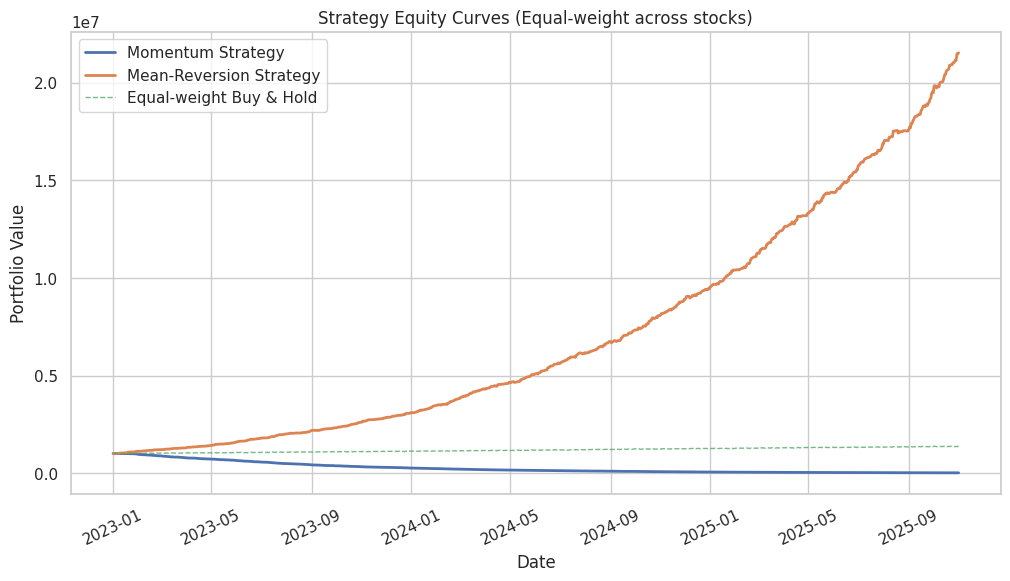


Momentum trade stats (summary): {'Long_Days': 5123, 'Pct_Days_Long': 0.4944980694980695, 'Avg_Daily_Ret_While_Long': -0.00803106944067769}
Mean-reversion trade stats (summary): {'Long_Days': 1407, 'Pct_Days_Long': 0.1358108108108108, 'Avg_Daily_Ret_While_Long': 0.021928785936030395}


Avg_Daily_Ret
-0.0017988310898278091
-0.0019032651985949412
-0.0020298375844364004
-0.0025552390186283445
-0.0030358467109777394
-0.003121482267689333
-0.003787361664996365
-0.0054846363580209
-0.005859304445705964
-0.010137679005322787



Done — Use Case 4 backtest completed. You can customize lookbacks, thresholds, weighting scheme, or add transaction costs and slippage for realism.


In [0]:
# Databricks notebook cell: Use Case 4 - Algorithmic Trading Strategy Analytics (Simple backtest)
# ----------------------------------------------------------------------------------------------
from pyspark.sql.functions import col, to_date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
input_table = "default.synthetic_stock_market_full"   # change if different
stocks_to_use = None   # None -> all stocks; or provide list e.g. ["TCS","INFY"]
start_date = None      # optionally filter start date e.g. "2023-01-01"
momentum_lookback = 20
meanrev_lookback = 5
meanrev_threshold = -0.02   # -2% last 5-day return triggers mean-reversion long
initial_capital = 1_000_000
trading_days = 252
risk_free_rate = 0.06
random_seed = 42

# ---------------- HELPERS ----------------
def performance_stats(equity_series, trading_days=252, rf=0.06):
    """
    equity_series: pandas Series of equity values indexed by date (chronological)
    returns daily simple returns computed from equity_series
    """
    eq = equity_series.dropna()
    if len(eq) < 2:
        return {}
    daily_ret = eq.pct_change().dropna()
    total_return = eq.iloc[-1] / eq.iloc[0] - 1.0
    days = (eq.index[-1] - eq.index[0]).days
    years = days / 365.25 if days > 0 else len(eq)/trading_days
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1.0 / years) - 1 if years > 0 else np.nan
    ann_vol = daily_ret.std() * np.sqrt(trading_days)
    sharpe = (daily_ret.mean() * trading_days - rf) / ann_vol if ann_vol != 0 else np.nan
    # max drawdown
    cum_max = eq.cummax()
    drawdown = (eq - cum_max) / cum_max
    max_dd = drawdown.min()
    return {
        "Total_Return": total_return,
        "CAGR": cagr,
        "Annual_Volatility": ann_vol,
        "Sharpe": sharpe,
        "Max_Drawdown": max_dd
    }

# ---------------- LOAD DATA ----------------
try:
    sdf = spark.table(input_table)
except Exception:
    try:
        sdf = df
    except NameError:
        raise RuntimeError(f"Could not find Spark table '{input_table}' or variable 'df'")

sdf = sdf.withColumn("Date", to_date(col("Date")))

if stocks_to_use is None:
    stocks_list = [r.Stock_Symbol for r in sdf.select("Stock_Symbol").distinct().collect()]
else:
    stocks_list = stocks_to_use

# Build price wide pandas DataFrame (Date x Stocks of Close_Price)
pdf = sdf.select("Date", "Stock_Symbol", "Close_Price") \
         .toPandas()
pdf['Date'] = pd.to_datetime(pdf['Date'])
pdf = pdf.sort_values(['Date', 'Stock_Symbol'])
price_wide = pdf.pivot(index='Date', columns='Stock_Symbol', values='Close_Price')
price_wide = price_wide[stocks_list]  # reorder / filter
price_wide = price_wide.dropna(how='any')  # drop dates with missing prices

# ---------------- SIGNALS & BACKTEST (vectorized per-stock) ----------------
returns = price_wide.pct_change().fillna(0)

# Momentum signal: long next day if past momentum_lookback-day return > 0
past_return_mom = price_wide.pct_change(periods=momentum_lookback)
mom_signal = (past_return_mom > 0).shift(1).fillna(0).astype(int)  # 1 = long, 0 = flat

# Mean-reversion signal: long next day if past meanrev_lookback-day return < threshold
past_return_meanrev = price_wide.pct_change(periods=meanrev_lookback)
mr_signal = (past_return_meanrev < meanrev_threshold).shift(1).fillna(0).astype(int)

# Strategy returns (per stock) = signal * daily return
mom_strategy_ret = mom_signal * returns
mr_strategy_ret = mr_signal * returns

# Equal-weight portfolio across stocks: average across columns (simple)
mom_portfolio_ret = mom_strategy_ret.mean(axis=1)
mr_portfolio_ret = mr_strategy_ret.mean(axis=1)

# Equity curves (starting from initial_capital)
mom_equity = (1 + mom_portfolio_ret).cumprod() * initial_capital
mr_equity  = (1 + mr_portfolio_ret).cumprod() * initial_capital
buy_and_hold_equity = (1 + returns.mean(axis=1)).cumprod() * initial_capital  # benchmark: equal-weight buy & hold

# ---------------- PERFORMANCE METRICS ----------------
mom_stats = performance_stats(mom_equity, trading_days, risk_free_rate)
mr_stats  = performance_stats(mr_equity, trading_days, risk_free_rate)
bh_stats  = performance_stats(buy_and_hold_equity, trading_days, risk_free_rate)

print("Momentum Strategy (equal-weight) metrics:")
print(mom_stats)
print("\nMean-Reversion Strategy (equal-weight) metrics:")
print(mr_stats)
print("\nBuy & Hold Benchmark metrics:")
print(bh_stats)

# ---------------- PLOT EQUITY CURVES ----------------
plt.figure(figsize=(12,6))
plt.plot(mom_equity.index, mom_equity.values, label='Momentum Strategy', linewidth=2)
plt.plot(mr_equity.index, mr_equity.values, label='Mean-Reversion Strategy', linewidth=2)
plt.plot(buy_and_hold_equity.index, buy_and_hold_equity.values, label='Equal-weight Buy & Hold', linewidth=1, linestyle='--', alpha=0.8)
plt.title("Strategy Equity Curves (Equal-weight across stocks)")
plt.xlabel("Date"); plt.ylabel("Portfolio Value")
plt.legend(); plt.grid(True); plt.xticks(rotation=25)
plt.show()

# ---------------- TRADE STATISTICS (summary) ----------------
def trade_stats_from_signals(sig_df, ret_df):
    """Compute simple trade stats: number of long days, avg daily return while long, pct days long"""
    long_days = sig_df.sum().sum()
    total_days = sig_df.shape[0] * sig_df.shape[1]
    pct_long = long_days / total_days
    avg_ret_long = (sig_df * ret_df).sum().sum() / (sig_df.sum().sum()) if sig_df.sum().sum() > 0 else 0.0
    return {"Long_Days": int(long_days), "Pct_Days_Long": pct_long, "Avg_Daily_Ret_While_Long": avg_ret_long}

mom_trade_stats = trade_stats_from_signals(mom_signal, returns)
mr_trade_stats  = trade_stats_from_signals(mr_signal, returns)

print("\nMomentum trade stats (summary):", mom_trade_stats)
print("Mean-reversion trade stats (summary):", mr_trade_stats)

# ---------------- OPTIONAL: per-stock top performers for momentum strategy ----------------
# average strategy return per stock
mom_avg_by_stock = mom_strategy_ret.mean().sort_values(ascending=False).to_frame("Avg_Daily_Ret")
display(mom_avg_by_stock.head(10))

# ---------------- DONE ----------------
print("\nDone — Use Case 4 backtest completed. You can customize lookbacks, thresholds, weighting scheme, or add transaction costs and slippage for realism.")


Date,Stock_Symbol,Price,Return,ZScore,VolShort,VolLongMean,AnomType
2025-10-31T00:00:00.000Z,INFY,3357.17,-0.0028513976303696786,-0.1852198624236255,0.012173666932748836,0.009306875339977087,VolSpike
2025-10-30T00:00:00.000Z,INFY,3366.77,-0.007499535700914772,-0.6060004229871764,0.0123259494103985,0.009306875339977087,VolSpike
2025-10-29T00:00:00.000Z,INFY,3392.21,0.01873062969992545,1.5219687891996363,0.012354329578662266,0.009306875339977087,VolSpike
2025-10-28T00:00:00.000Z,INFY,3329.84,-0.021225437603797692,-1.704104497494272,0.012445760645155604,0.009306875339977087,VolSpike
2025-10-27T00:00:00.000Z,ADANIPORTS,912.75,-0.07723803265429907,-1.9315555474222972,0.0392848147181291,0.03381606281388411,Bollinger
2025-10-27T00:00:00.000Z,INFY,3402.05,0.009558317308833608,0.7747992981080732,0.01196720762967635,0.009306875339977087,VolSpike
2025-10-26T00:00:00.000Z,INFY,3369.84,0.0029524512488392496,0.2059249815305814,0.012127735620666193,0.009306875339977087,VolSpike
2025-10-25T00:00:00.000Z,INFY,3359.92,-0.0020256984501326736,-0.1872096232995188,0.012118835218216944,0.009306875339977087,VolSpike
2025-10-25T00:00:00.000Z,TCS,1200.42,-0.04655171044375428,-1.3245587352752024,0.03479089332322695,0.026893678198367615,VolSpike
2025-10-24T00:00:00.000Z,ICICI,2536.24,0.017128328113156677,1.3842282381135274,0.011584296809642597,0.012649083588562903,Bollinger


Visualizing: INFY


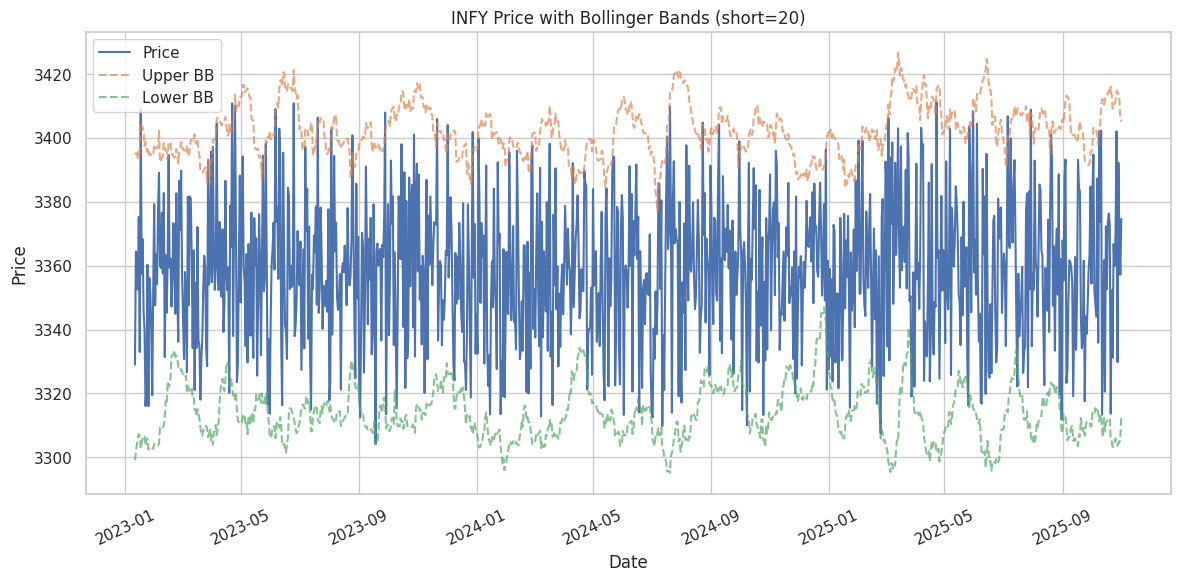

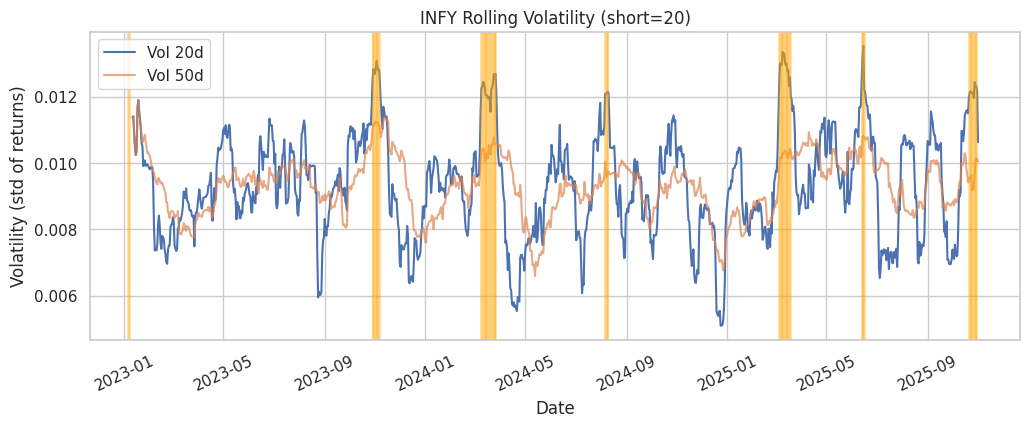

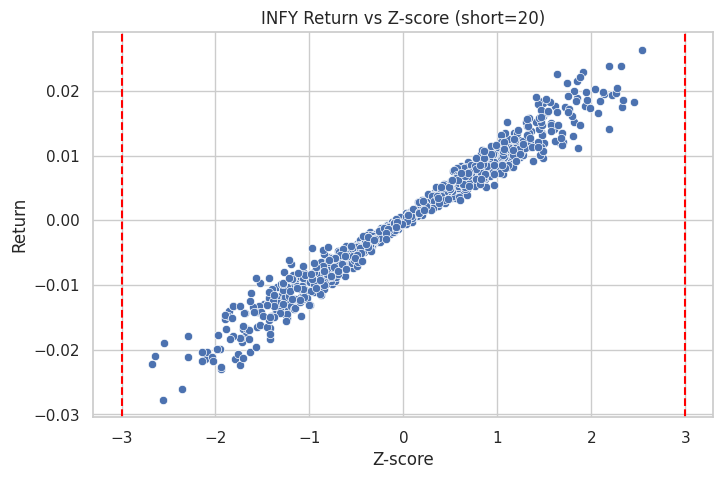

Total anomalies detected: 571
Anomalies by type (sample):
VolSpike            328
Bollinger           242
ZScore,Bollinger      1
Name: AnomType, dtype: int64
Volatility & anomaly detection completed. Adjust thresholds (z_threshold, vol_spike_multiplier) to tune sensitivity.


In [0]:
# Databricks notebook cell: Use Case 5 - Volatility & Anomaly Detection
# ---------------------------------------------------------------------
from pyspark.sql.functions import col, to_date
from pyspark.sql import Window
from pyspark.sql.functions import avg, stddev
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- CONFIG ----------------
input_table = "default.synthetic_stock_market_full"  # change if your table is different
stock_focus = None   # e.g., "TCS" to focus on one stock, or None for portfolio-level detection
rolling_short = 20   # short window for volatility / Bollinger
rolling_long  = 50   # long window for baseline vol
z_threshold = 3.0    # z-score threshold to flag anomalies
vol_spike_multiplier = 3.0  # mult * baseline std to flag volatility spike
sample_fraction_for_plot = 0.20
random_seed = 42

# ---------------- LOAD DATA ----------------
try:
    sdf = spark.table(input_table)
except Exception:
    try:
        sdf = df
    except NameError:
        raise RuntimeError(f"Could not find table '{input_table}' or variable 'df' in notebook.")

# ensure Date type and select relevant cols
sdf = sdf.withColumn("Date", to_date(col("Date")))
sdf = sdf.select("Date", "Stock_Symbol", "Open_Price", "High_Price", "Low_Price", "Close_Price", "Volume")

if stock_focus:
    sdf = sdf.filter(col("Stock_Symbol") == stock_focus)

# pivot to wide format (Date x Stocks) for price series processing (pandas is easier here)
pdf = sdf.select("Date", "Stock_Symbol", "Close_Price").toPandas()
pdf['Date'] = pd.to_datetime(pdf['Date'])
pdf = pdf.sort_values(['Date', 'Stock_Symbol'])

price_wide = pdf.pivot(index='Date', columns='Stock_Symbol', values='Close_Price')
price_wide = price_wide.dropna(how='any')  # drop rows with missing prices

# ---------------- CALCULATE RETURNS & ROLLING METRICS ----------------
returns = price_wide.pct_change().dropna(how='any')  # daily returns (decimal)

# Rolling volatility (std of returns)
vol_short = returns.rolling(window=rolling_short, min_periods=5).std()  # short-term vol
vol_long  = returns.rolling(window=rolling_long,  min_periods=10).std()  # long-term baseline vol

# Bollinger bands on price (using short rolling mean/std)
price_mean = price_wide.rolling(window=rolling_short, min_periods=5).mean()
price_std  = price_wide.rolling(window=rolling_short, min_periods=5).std()
upper_band = price_mean + 2 * price_std
lower_band = price_mean - 2 * price_std

# Rolling mean/std of returns for z-score
ret_mean_short = returns.rolling(window=rolling_short, min_periods=5).mean()
ret_std_short  = returns.rolling(window=rolling_short, min_periods=5).std()
zscore = (returns - ret_mean_short) / ret_std_short

# ---------------- ANOMALY CONDITIONS ----------------
# 1) Return z-score anomaly
anomaly_z = (zscore.abs() >= z_threshold)

# 2) Price outside Bollinger bands (strong breakout)
anomaly_bb = ( (price_wide > upper_band) | (price_wide < lower_band) )

# 3) Volatility spike: short vol > mean(long vol) + multiplier * std(long vol)
# compute baseline (per asset) stats from vol_long time series (ignore NaNs)
vol_long_mean = vol_long.mean()
vol_long_std  = vol_long.std()
vol_spike = (vol_short > (vol_long_mean + vol_spike_multiplier * vol_long_std))

# Combine anomalies
combined_anomaly = (anomaly_z | anomaly_bb | vol_spike)

# ---------------- SUMMARIZE ANOMALIES ----------------
# Create a tidy DataFrame of anomaly events
anomaly_events = []
for col_sym in combined_anomaly.columns:
    # find dates where anomaly True
    dates = combined_anomaly.index[combined_anomaly[col_sym].fillna(False)]
    for d in dates:
        anomaly_events.append({
            "Date": d,
            "Stock_Symbol": col_sym,
            "Price": float(price_wide.loc[d, col_sym]),
            "Return": float(returns.loc[d, col_sym]) if d in returns.index else None,
            "ZScore": float(zscore.loc[d, col_sym]) if d in zscore.index else None,
            "VolShort": float(vol_short.loc[d, col_sym]) if d in vol_short.index else None,
            "VolLongMean": float(vol_long_mean[col_sym]) if col_sym in vol_long_mean.index else None,
            "AnomType": ",".join([
                t for t, cond in [
                    ("ZScore", bool(anomaly_z.loc[d, col_sym]) if d in anomaly_z.index else False),
                    ("Bollinger", bool(anomaly_bb.loc[d, col_sym]) if d in anomaly_bb.index else False),
                    ("VolSpike", bool(vol_spike.loc[d, col_sym]) if d in vol_spike.index else False)
                ] if cond
            ])
        })

anomaly_df = pd.DataFrame(anomaly_events)
if anomaly_df.shape[0] == 0:
    print("No anomalies detected with current thresholds.")
else:
    # sort newest first
    anomaly_df = anomaly_df.sort_values(['Date','Stock_Symbol'], ascending=[False, True]).reset_index(drop=True)
    display(anomaly_df.head(20))

# ---------------- PLOTTING: choose a stock to visualize ----------------
# choose a stock with anomalies (if any), else pick first symbol
symbols = price_wide.columns.tolist()
viz_symbol = None
if len(anomaly_df) > 0:
    viz_symbol = anomaly_df.loc[0, 'Stock_Symbol']
else:
    viz_symbol = symbols[0]

print("Visualizing:", viz_symbol)

# Build pandas DF for plotting for viz_symbol
plot_df = pd.DataFrame({
    "Price": price_wide[viz_symbol],
    "Return": returns[viz_symbol],
    "VolShort": vol_short[viz_symbol],
    "VolLong": vol_long[viz_symbol],
    "UpperBB": upper_band[viz_symbol],
    "LowerBB": lower_band[viz_symbol],
    "ZScore": zscore[viz_symbol]
}).dropna().reset_index()

# Plot price with Bollinger Bands and anomaly markers
plt.figure(figsize=(14,6))
plt.plot(plot_df['Date'], plot_df['Price'], label='Price')
plt.plot(plot_df['Date'], plot_df['UpperBB'], label='Upper BB', linestyle='--', alpha=0.7)
plt.plot(plot_df['Date'], plot_df['LowerBB'], label='Lower BB', linestyle='--', alpha=0.7)
# mark zscore anomalies
anom_dates_z = anomaly_df[(anomaly_df['Stock_Symbol']==viz_symbol) & (anomaly_df['AnomType'].str.contains("ZScore"))]['Date'].tolist()
for d in anom_dates_z:
    plt.axvline(d, color='red', alpha=0.3)
plt.title(f"{viz_symbol} Price with Bollinger Bands (short={rolling_short})")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.xticks(rotation=25); plt.grid(True)
plt.show()

# Plot rolling vol and highlight spikes
plt.figure(figsize=(12,4))
plt.plot(plot_df['Date'], plot_df['VolShort'], label=f'Vol {rolling_short}d')
plt.plot(plot_df['Date'], plot_df['VolLong'], label=f'Vol {rolling_long}d' if 'VolLong' in plot_df.columns else 'LongVol', alpha=0.7)
# highlight vol spike dates
anom_dates_vs = anomaly_df[(anomaly_df['Stock_Symbol']==viz_symbol) & (anomaly_df['AnomType'].str.contains("VolSpike"))]['Date'].tolist()
for d in anom_dates_vs:
    plt.axvline(d, color='orange', alpha=0.3)
plt.title(f"{viz_symbol} Rolling Volatility (short={rolling_short})")
plt.xlabel("Date"); plt.ylabel("Volatility (std of returns)")
plt.legend(); plt.xticks(rotation=25); plt.grid(True)
plt.show()

# Scatter: Return vs Z-score (outliers)
plt.figure(figsize=(8,5))
sns.scatterplot(x=plot_df['ZScore'], y=plot_df['Return'])
plt.axvline(z_threshold, color='red', linestyle='--')
plt.axvline(-z_threshold, color='red', linestyle='--')
plt.title(f"{viz_symbol} Return vs Z-score (short={rolling_short})")
plt.xlabel("Z-score"); plt.ylabel("Return")
plt.grid(True)
plt.show()

# ---------------- SUMMARY METRICS ----------------
total_anomalies = len(anomaly_df)
by_type = anomaly_df['AnomType'].value_counts() if total_anomalies>0 else {}
print("Total anomalies detected:", total_anomalies)
print("Anomalies by type (sample):")
print(by_type.head(10))

# ---------------- DONE ----------------
print("Volatility & anomaly detection completed. Adjust thresholds (z_threshold, vol_spike_multiplier) to tune sensitivity.")
